1. Data Loading & Cleaning

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


mortality = pd.read_excel("data/UNIGME-2025-UNICEFRegion-Rates-Deaths-Sex-specific-5-to-24.xlsx",sheet_name="20q5, 10q10",skiprows=14)

mortality.columns = mortality.columns.str.strip()

mortality = mortality[["Region", "Sex", "Year", "Median"]] #data analizi için only relevant variablesları seçtim

mortality = mortality.rename(columns={
    "Median": "mort_median_5_24"
})

mortality = mortality.groupby(["Region", "Year"])["mort_median_5_24"].mean().reset_index()
# veriyi region + year bazında ortalama alarak özetliyoruz, ayrıca bu adımla sex ve region level kısmını datasetten çıkardık
hdi = pd.read_excel(
    "data/HDR25_Statistical_Annex_HDI_Table.xlsx",
    skiprows=4,
    usecols="B:C"
)

hdi.columns = ["Country", "HDI"]
hdi = hdi.iloc[2:].reset_index(drop=True)#gereksiz satırları silip index’i resetledim
hdi.head()

econ = pd.read_excel(
    "data/19-Economic-Indicators-SOWC2025-1.xlsx",
    skiprows=6,
    header=None,
    usecols=[1, 6, 8]
)

econ.columns = ["Country", "health_spending", "education_spending"]

econ = econ.iloc[1:].reset_index(drop=True)

econ["health_spending"] = pd.to_numeric(econ["health_spending"], errors="coerce")
econ["education_spending"] = pd.to_numeric(econ["education_spending"], errors="coerce")


mapping = pd.read_excel("data/JME_Regional-Classifications.xlsx")

mapping = mapping[["Country", "UNICEF Region"]]
mapping = mapping.rename(columns={"UNICEF Region": "UNICEF Region"})
mapping.head()



,Country,UNICEF Region
0,Afghanistan,ROSA
1,Albania,ECA
2,Algeria,MENA
3,Andorra,ECA
4,Angola,SSA


In [75]:
econ = econ.merge(mapping, on="Country", how="left")#burada econ datasındaki ülkelere, mapping datasından hangi bölgeye ait olduklarını ekledik
econ.head()

,Country,health_spending,education_spending,UNICEF Region
0,Afghanistan,0.720916,4.34319,ROSA
1,Albania,2.884195,2.74931,ECA
2,Algeria,3.267783,6.29900,MENA
3,Andorra,6.167981,2.66623,ECA
4,Angola,1.711142,2.33200,SSA


In [76]:
hdi = hdi.merge(mapping, on="Country", how="left")#burada da HDI verisindeki ülkelere hangi bölgeye ait olduklarını ekledik
hdi.head()

,Country,HDI,UNICEF Region
0,Very high human development,NaN,NaN
1,Iceland,0.972,ECA
2,Norway,0.97,ECA
3,Switzerland,0.97,ECA
4,Denmark,0.962,ECA


In [77]:
hdi = hdi.rename(columns={"UNICEF Region": "Region"})
hdi["HDI"] = pd.to_numeric(hdi["HDI"], errors="coerce")

hdi_region = hdi.groupby("Region")["HDI"].mean().reset_index()#ülkeleri bölgelere göre gruplayıp ortalama HDI hesaplıyoruz
hdi_region.head(10)

,Region,HDI
0,EAPRO,0.735857
1,ECA,0.882796
2,LACRO,0.768424
3,MENA,0.776778
4,ROSA,0.659000
5,SSA,0.561587


In [78]:
region_map = {
    "EAPRO": "East Asia and Pacific",
    "ECA": "Europe and Central Asia",
    "LACRO": "Latin America and Caribbean",
    "MENA": "Middle East and North Africa",
    "ROSA": "South Asia",
    "SSA": "Sub-Saharan Africa"
}
#burada kısaltılmış region kodlarını tam isimlere çevirmek için mapping oluşturdum(gpt söyledi)
hdi_region["Region"] = hdi_region["Region"].replace(region_map)
hdi_region

,Region,HDI
0,East Asia and Pacific,0.735857
1,Europe and Central Asia,0.882796
2,Latin America and Caribbean,0.768424
3,Middle East and North Africa,0.776778
4,South Asia,0.659000
5,Sub-Saharan Africa,0.561587


alltaki kodda: Ülkeleri bölgelere göre gruplayıp:
	•	health spending ortalaması
	•	education spending ortalaması aldık
(groupby ile)

In [79]:
econ_region = econ.groupby("UNICEF Region")[["health_spending", "education_spending"]].mean().reset_index()
econ_region["UNICEF Region"] = econ_region["UNICEF Region"].replace(region_map)

econ_region.head()

,UNICEF Region,health_spending,education_spending
0,East Asia and Pacific,4.563424,4.522219
1,Europe and Central Asia,5.864425,4.702014
2,Latin America and Caribbean,4.406373,4.369904
3,Middle East and North Africa,3.170344,4.231401
4,South Asia,2.020454,3.786024


In [80]:
econ_region = econ_region.rename(columns={"UNICEF Region": "Region"})
econ_region.head()

,Region,health_spending,education_spending
0,East Asia and Pacific,4.563424,4.522219
1,Europe and Central Asia,5.864425,4.702014
2,Latin America and Caribbean,4.406373,4.369904
3,Middle East and North Africa,3.170344,4.231401
4,South Asia,2.020454,3.786024


In [81]:
df = mortality.merge(hdi_region, on="Region", how="left") #burada mortality datasına hdi ekledim
df = df.merge(econ_region, on="Region", how="left")#burada da economic verileri ekledim

df.head()

,Region,Year,mort_median_5_24,HDI,health_spending,education_spending
0,East Asia and Pacific,1990,18.477822,0.735857,4.563424,4.522219
1,East Asia and Pacific,1991,18.001312,0.735857,4.563424,4.522219
2,East Asia and Pacific,1992,17.444175,0.735857,4.563424,4.522219
3,East Asia and Pacific,1993,16.978292,0.735857,4.563424,4.522219
4,East Asia and Pacific,1994,16.549464,0.735857,4.563424,4.522219


In [82]:
df.isnull().sum()#merge sonrası verileri kontrol eder her sütun biribriyle eşleniyor mu boş veri var mı diye

Region                  0
Year                    0
mort_median_5_24        0
HDI                   210
health_spending       210
education_spending    210
dtype: int64

In [83]:
fix_map = {
    "Eastern Europe and Central Asia": "Europe and Central Asia",
    "Western Europe": "Europe and Central Asia",
    "Eastern and Southern Africa": "Sub-Saharan Africa",
    "West and Central Africa": "Sub-Saharan Africa",
    "North America": "Europe and Central Asia",  # approx (dataset'e göre kabul)
    "World": None  # bunu istemiyoruz
}

df["Region"] = df["Region"].replace(fix_map)#mortality datasetindeki region isimlerini diğer datasetlerle uyumlu hale getirdik

In [84]:
df = mortality.copy()
df["Region"] = df["Region"].replace(fix_map)

df = df.merge(hdi_region, on="Region", how="left")
df = df.merge(econ_region, on="Region", how="left")

In [85]:
df.isnull().sum()

Region                35
Year                   0
mort_median_5_24       0
HDI                   35
health_spending       35
education_spending    35
dtype: int64

In [86]:
df = df[df["Region"].notna()].reset_index(drop=True)# burada region değeri boş (NaN) olan satırları sildik, sonra index’i sıfırlayıp düzenledik

In [87]:
df.isnull().sum()

Region                0
Year                  0
mort_median_5_24      0
HDI                   0
health_spending       0
education_spending    0
dtype: int64

In [88]:
df.describe()#burada da tüm data cleaning işlemleri sonucundaki özet istatistikleri veriyor

,Year,mort_median_5_24,HDI,health_spending,education_spending
count,385.000000,385.000000,385.000000,385.000000,385.000000
mean,2007.000000,24.998897,0.741455,3.919837,4.316662
std,10.112647,21.123060,0.130124,1.734485,0.356637
min,1990.000000,3.720566,0.561587,1.833304,3.786024
25%,1998.000000,9.734127,0.561587,1.833304,3.921891
50%,2007.000000,15.814418,0.768424,4.406373,4.369904
75%,2016.000000,36.756472,0.882796,5.864425,4.702014
max,2024.000000,117.836929,0.882796,5.864425,4.702014


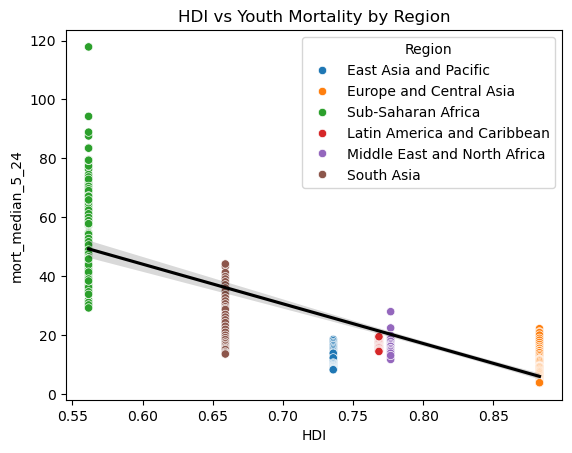

In [89]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    data=df,
    x="HDI",
    y="mort_median_5_24",
    hue="Region"
)

sns.regplot(
    data=df,
    x="HDI",
    y="mort_median_5_24",
    scatter=False,
    color="black"
)

plt.title("HDI vs Youth Mortality by Region")
plt.show()

The scatterplot shows a negative relationship between HDI and youth mortality. Countries with low HDI, especially in Sub-Saharan Africa, have higher and more spread mortality rates. Countries with high HDI, like Europe and Central Asia, have lower and more stable mortality.

This means that as development increases, mortality decreases and becomes more stable.s

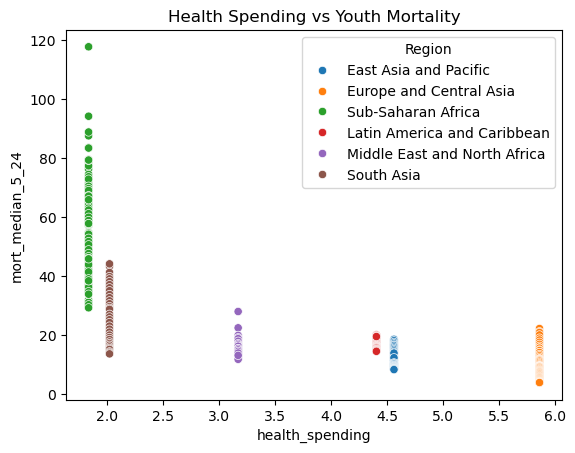

In [90]:
sns.scatterplot(data=df, x="health_spending", y="mort_median_5_24", hue="Region")
plt.title("Health Spending vs Youth Mortality")
plt.show()

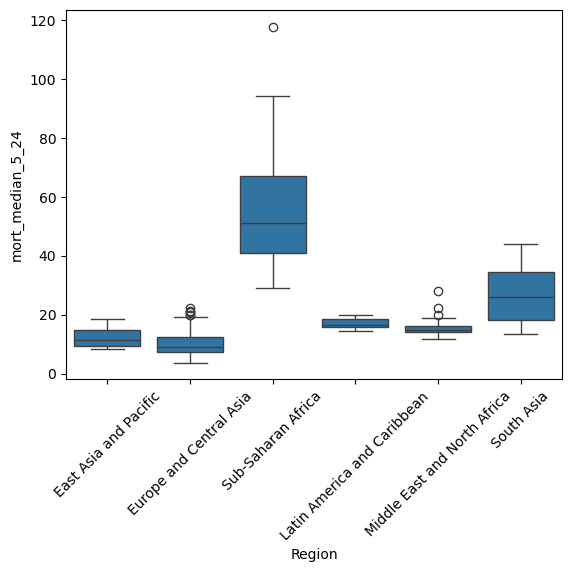

In [91]:
sns.boxplot(data=df, x="Region", y="mort_median_5_24")
plt.xticks(rotation=45)
plt.show()

 Region-based interpretation

🔴 Sub-Saharan Africa
	•	Very high median (~50+)
	•	Very wide spread (30 → 120)
👉 worst outcomes + highest uncertainty

⸻

🟡 South Asia
	•	Moderate levels (~20–40)
👉 developing → still at risk

⸻

🟢 Europe & Central Asia
	•	Lowest levels (~5–15)
	•	Very stable
👉 best performance

⸻

🟢 East Asia & Pacific / Latin America & Caribbean / Middle East & North Africa
	•	Low to moderate levels (~10–20)
👉 transition regions

Overall, the boxplot reveals a clear gradient in youth mortality across regions, where more developed regions exhibit both lower and more stable mortality rates, while less developed regions face higher and more variable outcomes.

In [92]:
df.groupby("Region")["mort_median_5_24"].mean().sort_values()

Region
Europe and Central Asia          9.985477
East Asia and Pacific           12.149831
Middle East and North Africa    15.627380
Latin America and Caribbean     16.945456
South Asia                      26.685995
Sub-Saharan Africa              54.545766
Name: mort_median_5_24, dtype: float64

In [93]:
df[["HDI", "mort_median_5_24"]].corr()

,HDI,mort_median_5_24
HDI,1.000000,-0.830574
mort_median_5_24,-0.830574,1.000000


In [94]:
from scipy.stats import pearsonr

corr, p_value = pearsonr(df["HDI"], df["mort_median_5_24"])

print(corr, p_value)

-0.8305742900201275 2.11441803756972e-99


In [95]:
from scipy.stats import f_oneway

groups = [group["mort_median_5_24"].values for name, group in df.groupby("Region")]

f_stat, p_value = f_oneway(*groups)

print(f_stat, p_value)

276.25730462245025 5.677159046068467e-124


In [96]:
df[["health_spending", "education_spending", "mort_median_5_24"]].corr()

,health_spending,education_spending,mort_median_5_24
health_spending,1.000000,0.987001,-0.771455
education_spending,0.987001,1.000000,-0.741686
mort_median_5_24,-0.771455,-0.741686,1.000000


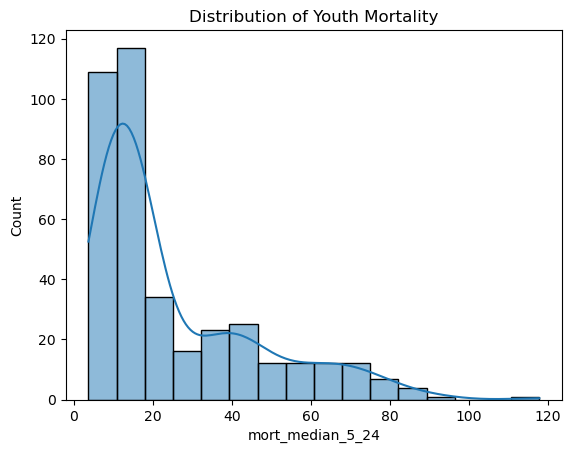

In [97]:
sns.histplot(df["mort_median_5_24"], kde=True)
plt.title("Distribution of Youth Mortality")
plt.show()

The distribution of youth mortality rates is right-skewed, indicating that most regions have relatively low mortality levels, while a smaller number of observations exhibit extremely high values.

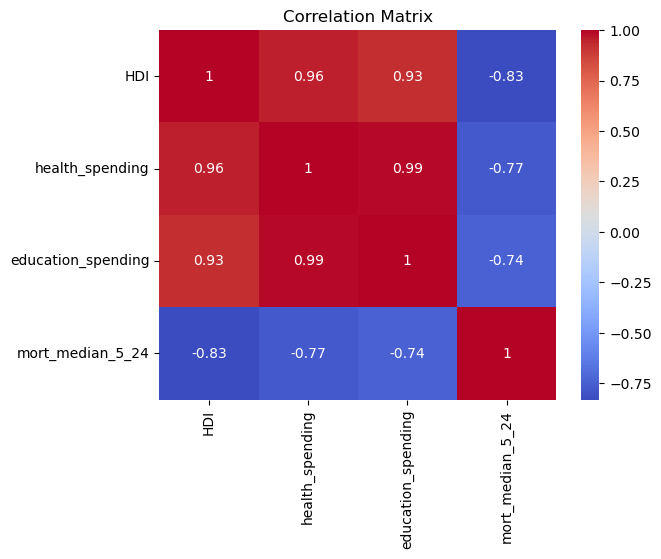

In [98]:
sns.heatmap(
    df[["HDI", "health_spending", "education_spending", "mort_median_5_24"]].corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Matrix")
plt.show()

Korelasyon matrisi, HDI, sağlık harcamaları ve eğitim harcamaları arasında güçlü pozitif ilişkiler olduğunu göstermektedir; bu da daha gelişmiş bölgelerin sosyal alanlara daha fazla yatırım yaptığını ortaya koymaktadır. Ayrıca, bu üç değişkenin genç ölüm oranları ile güçlü negatif ilişkiye sahip olması, gelişmişlik ve yatırım arttıkça ölüm oranlarının azaldığını göstermektedir.

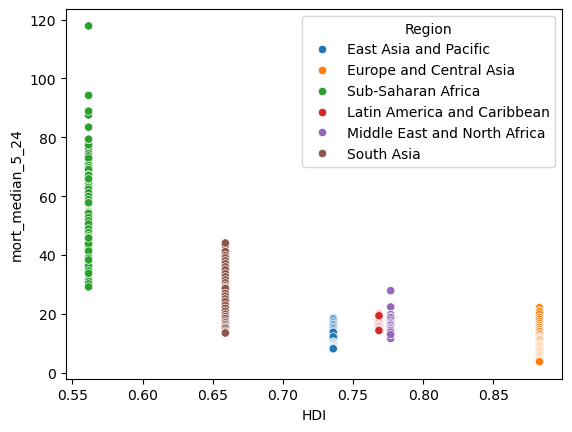

In [99]:
sns.scatterplot(data=df, x="HDI", y="mort_median_5_24", hue="Region")
plt.show()

The scatterplot reveals a strong negative relationship between HDI and youth mortality rates. Regions with lower HDI values exhibit both higher and more dispersed mortality rates, while regions with higher HDI show lower and more stable outcomes. This suggests that development not only reduces mortality but also decreases variability.

<Axes: xlabel='Region', ylabel='mort_median_5_24'>

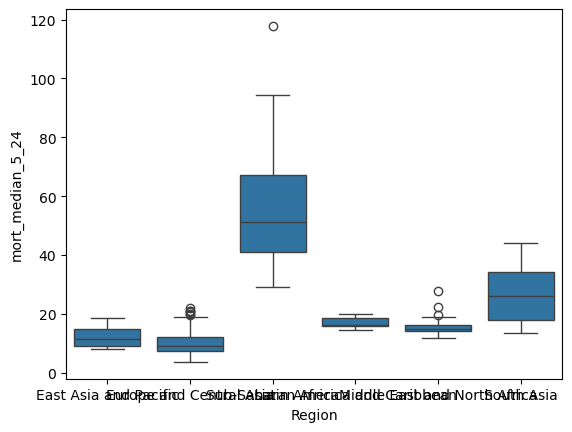

In [100]:
sns.boxplot(data=df, x="Region", y="mort_median_5_24")

The boxplot highlights clear regional disparities in youth mortality rates. Sub-Saharan Africa exhibits both the highest median and the greatest variability, indicating severe and uneven outcomes. In contrast, more developed regions such as Europe and Central Asia display significantly lower and more stable mortality rates. This demonstrates that inequality exists not only between countries but also across regions.

In [101]:
median_hdi = df["HDI"].median()

df["HDI_group"] = df["HDI"].apply(lambda x: "High HDI" if x >= median_hdi else "Low HDI")

In [102]:
from scipy.stats import ttest_ind

high = df[df["HDI_group"] == "High HDI"]["mort_median_5_24"]
low = df[df["HDI_group"] == "Low HDI"]["mort_median_5_24"]

t_stat, p_value = ttest_ind(high, low)

print(t_stat, p_value)

-17.68897228707851 1.3095887736296123e-51


🎯 HYPOTHESIS 2 

🧠 Fikir:

👉 “Sağlık mı eğitim mi daha güçlü etkiye sahip?”

H0:
Health ve education spending’in mortality ile ilişkisi aynıdır

H1:
Birisi daha güçlü ilişkiye sahiptir

In [103]:
df[["health_spending", "education_spending", "mort_median_5_24"]].corr()

,health_spending,education_spending,mort_median_5_24
health_spending,1.000000,0.987001,-0.771455
education_spending,0.987001,1.000000,-0.741686
mort_median_5_24,-0.771455,-0.741686,1.000000


p-value (correlation testi) == “bu gerçek mi?” testi

In [104]:
from scipy.stats import pearsonr

corr, p_value = pearsonr(df["HDI"], df["mort_median_5_24"])
print(corr, p_value)

-0.8305742900201275 2.11441803756972e-99


The relationship is statistically significant (p < 0.001).

 ANOVA = “gruplar gerçekten farklı mı?” testi

In [105]:
from scipy.stats import f_oneway

groups = [group["mort_median_5_24"].values for name, group in df.groupby("Region")]

f_stat, p_value = f_oneway(*groups)

print(f_stat, p_value)

276.25730462245025 5.677159046068467e-124


💣 HYPOTHESIS 1 (çok iyi ve farklı)

🧠 Fikir:

👉 “Gelişmişlik arttıkça sadece mortality düşmüyor, değişkenlik (variance) da düşüyor mu?”

⸻

🧪 Hypothesis

H0:
High HDI ve Low HDI gruplarının mortality variance’ı aynıdır

H1:
High HDI grubunda mortality daha az değişkendir

In [106]:
high = df[df["HDI"] >= df["HDI"].median()]["mort_median_5_24"]
low = df[df["HDI"] < df["HDI"].median()]["mort_median_5_24"]

high.var(), low.var()

(23.444783186404887, 513.7750122562574)

Development reduces not only mortality but also uncertainty.

🧪 Hypothesis3

🇬🇧

H0:
After controlling for HDI, regions do not differ in youth mortality

H1:
Even after controlling for HDI, regions still differ

In [107]:
import statsmodels.api as sm

X = df[["HDI"]]
y = df["mort_median_5_24"]

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:       mort_median_5_24   R-squared:                       0.690
Model:                            OLS   Adj. R-squared:                  0.689
Method:                 Least Squares   F-statistic:                     851.9
Date:                Sun, 12 Apr 2026   Prob (F-statistic):           2.11e-99
Time:                        16:45:39   Log-Likelihood:                -1494.8
No. Observations:                 385   AIC:                             2994.
Df Residuals:                     383   BIC:                             3002.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        124.9671      3.477     35.938      0.0

interpretation for this: HDI has a strong and statistically significant negative effect on youth mortality (β = -134.82, p < 0.001). This suggests that higher development levels are associated with substantially lower mortality rates. The model explains a large portion of the variation in mortality (R² = 0.69), indicating that HDI alone is a powerful predictor.

In [108]:
import statsmodels.formula.api as smf

model = smf.ols("mort_median_5_24 ~ HDI + C(Region)", data=df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:       mort_median_5_24   R-squared:                       0.785
Model:                            OLS   Adj. R-squared:                  0.782
Method:                 Least Squares   F-statistic:                     276.3
Date:                Sun, 12 Apr 2026   Prob (F-statistic):          5.68e-124
Time:                        16:45:39   Log-Likelihood:                -1424.6
No. Observations:                 385   AIC:                             2861.
Df Residuals:                     379   BIC:                             2885.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                                coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------

A regression model including both HDI and region indicates that some regional differences remain significant even after controlling for development. In particular, Sub-Saharan Africa and South Asia show significantly higher mortality levels. However, the HDI coefficient is not statistically significant in this model, likely due to strong multicollinearity between HDI and regional structure.

Sonuç

H0’ı tamamen tutamıyoruz. Çünkü bazı region dummy’leri hâlâ anlamlı.
Yani:
HDI kontrol edilse bile bazı bölgeler mortality açısından farklı kalıyor.

Bu çok iyi bir insight.

Ama çok önemli bir uyarı da var:
Altta çıkan notta strong multicollinearity yazıyor.
Bu da şu demek:
	•	HDI ile Region çok iç içe geçmiş
	•	o yüzden modelde HDI anlamsız görünmüş olabilir
	•	yani “HDI önemsiz” demek doğru olmaz
	•	daha doğrusu: region eklendiğinde HDI’nin bağımsız etkisini ayırmak zorlaşıyor


therefore, although HDI is a strong predictor of youth mortality, its effect becomes insignificant when regional variables are included, suggesting that development is not independent but structurally tied to regional contexts